In [1]:
#imports#
import geopandas as gpd
import pandas as pd
#read geoJSON file#
file_path = '/home/pratush/Downloads/gadm41_IND_3.json'
gdf = gpd.read_file(file_path)

#select J&K row#
JKrow=gdf[gdf['NAME_1']=='JammuandKashmir']
#save the row as geoJSON file#
# output_file = '/home/pratush/Desktop/JKshape.geojson'
# JKrow.to_file(output_file, driver='GeoJSON')

In [2]:
display(JKrow)

,GID_3,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,GID_2,NAME_2,NL_NAME_2,NAME_3,VARNAME_3,NL_NAME_3,TYPE_3,ENGTYPE_3,CC_3,HASC_3,geometry
646,Z01.14.1.1_1,Z01,India,Z01.14_1,JammuandKashmir,NA,Z01.14.1_1,Anantnag,NA,n.a.(6),NA,NA,Taluk,Taluk,NA,NA,"MULTIPOLYGON (((75.48600 33.40970, 75.47760 33..."
647,Z01.14.2.1_1,Z01,India,Z01.14_1,JammuandKashmir,NA,Z01.14.2_1,Badgam,NA,n.a.(8),NA,NA,Taluk,Taluk,NA,NA,"MULTIPOLYGON (((74.56090 33.70290, 74.53520 33..."
648,Z01.14.3.1_1,Z01,India,Z01.14_1,JammuandKashmir,NA,Z01.14.3_1,Bandipore,NA,n.a.(4),NA,NA,Taluk,Taluk,NA,NA,"MULTIPOLYGON (((74.57720 34.76950, 74.58020 34..."
649,Z01.14.4.1_1,Z01,India,Z01.14_1,JammuandKashmir,NA,Z01.14.4_1,Baramulla,NA,n.a.(4),NA,NA,Taluk,Taluk,NA,NA,"MULTIPOLYGON (((74.25460 33.99730, 74.24870 34..."
650,Z01.14.5.1_1,Z01,India,Z01.14_1,JammuandKashmir,NA,Z01.14.5_1,Doda,NA,n.a.(7),NA,NA,Taluk,Taluk,NA,NA,"MULTIPOLYGON (((76.21620 33.02860, 76.18830 33..."
651,Z01.14.6.1_1,Z01,India,Z01.14_1,JammuandKashmir,NA,Z01.14.6_1,Ganderbal,NA,n.a.(5a),NA,NA,Taluk,Taluk,NA,NA,"MULTIPOLYGON (((74.65820 34.34950, 74.67640 34..."
652,Z01.14.6.2_1,Z01,India,Z01.14_1,JammuandKashmir,NA,Z01.14.6_1,Ganderbal,NA,n.a.(5b),NA,NA,Taluk,Taluk,NA,NA,"MULTIPOLYGON (((75.49280 34.21900, 75.46490 34..."
653,Z01.14.7.1_1,Z01,India,Z01.14_1,JammuandKashmir,NA,Z01.14.7_1,Jammu,NA,n.a.(16),NA,NA,Taluk,Taluk,NA,NA,"MULTIPOLYGON (((74.47200 32.77840, 74.46610 32..."
654,Z01.14.8.1_1,Z01,India,Z01.14_1,JammuandKashmir,NA,Z01.14.8_1,Kargil,NA,n.a.(3),NA,NA,Taluk,Taluk,NA,NA,"MULTIPOLYGON (((75.37780 34.55240, 75.39500 34..."
655,Z01.14.9.1_1,Z01,India,Z01.14_1,JammuandKashmir,NA,Z01.14.9_1,Kathua,NA,n.a.(20),NA,NA,Taluk,Taluk,NA,NA,"MULTIPOLYGON (((75.90460 32.61520, 75.88630 32..."


In [3]:
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
import tifffile as tiff
##---------Read the tif file---------##
image = tiff.imread('./gpw_v4_population_density_adjusted_to_2015_unwpp_country_totals_rev11_2020_15_min.tif')
image_array = np.array(image)


#----------Define the spherical coordinates----------#
theta = np.linspace(np.radians(0), np.radians(180), num=image_array.shape[0],endpoint=False)
phi = np.linspace(-np.radians(180), np.radians(180), num=image_array.shape[1],endpoint=False)

#---------- Set angular resolution----------#
nside = 128

##--------Make empty healpix mask and pixel values vector--------##
healpix_map = np.zeros(hp.nside2npix(nside), dtype=np.double)
pixel_counts = np.zeros(hp.nside2npix(nside), dtype=int)


for i in range(len(theta)):
    for j in range(len(phi)):
        pixel = hp.ang2pix(nside, theta[i], phi[j])
        healpix_map[pixel] += image_array[i, j]
        pixel_counts[pixel] += 1

#--------Average value of each pixel--------#
healpix_map[pixel_counts>0] /= pixel_counts[pixel_counts>0 ]




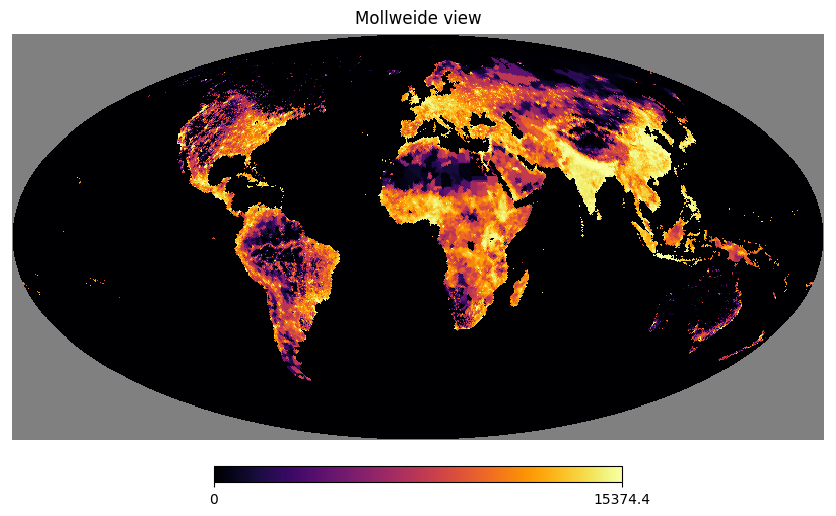

In [7]:
hp.mollview(healpix_map, cmap="inferno", flip="geo", norm="hist", min=0)
